In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'retina'

In [ ]:
%load_ext autoreload
%autoreload 1
%aimport qchannel_kernel
from qchannel_kernel import run_benchmark
from qutip import *
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix

for kind in ["linear", "poly", "rbf"]:
    res = run_benchmark(
        n=200, d=2, seed=0,
        kernel_kind=kind,
        poly_degree=2,     # only used for poly
        rbf_gamma=2.0,     # only used for rbf
        C=5.0
    )
    print(kind, res.acc, res.bacc, res.auc)

KeyboardInterrupt: 

In [16]:
# Benchmark on *general* qubit channels (random CPTP 2→2 via Kraus/Stinespring)
#
# Labels are computed via an SDP (CVXPY), so keep n small.

from qchannel_kernel import run_benchmark

# Start small; increase n only if it runs fast enough on your machine.
for kind in ["rbf"]:
    res = run_benchmark(
        n=40,
        d=2,
        seed=42,
        kernel_kind=kind,
        poly_degree=2,
        rbf_gamma=2.0,
        C=10.0,
        channel_family="random_qubit",
        kraus_rank=2,
    )
    print("random_qubit", kind, "acc=", res.acc, "bacc=", res.bacc, "auc=", res.auc, "compat_frac=", res.details["compatible_frac"])

c:\Users\sabar\anaconda3\envs\p-qlif\Lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


random_qubit rbf acc= 0.9166666666666666 bacc= 0.5 auc= 0.5454545454545454 compat_frac= 0.05


In [22]:
# Notebook cell 2 — run: train on depolarizing, test on random qubit channels
# NOTE: random_qubit labels use an SDP oracle -> requires `cvxpy` installed and working.

import importlib

import qchannel_kernel
importlib.reload(qchannel_kernel)

from qchannel_kernel import run_cross_family_benchmark

res = run_cross_family_benchmark(
    n_train=100,
    n_test=10,
    d=2,
    seed=42,
    kernel_kind="rbf",     # try "rbf" too
    poly_degree=2,
    poly_c=1.0,
    rbf_gamma=2.0,
    C=5.0,
    distribution="uniform", # depolarizing parameter sampling
    t_range=(0.0, 1.0),
    kraus_rank=2            # random channel Kraus rank
)

print(f"acc={res.acc:.4f}  bacc={res.bacc:.4f}  auc={res.auc:.4f}")
print("confusion matrix [[TN, FP],[FN, TP]]:\n", res.cm)
print("\nDetails:")
for k, v in res.details.items():
    print(f"  {k}: {v}")

c:\Users\sabar\anaconda3\envs\p-qlif\Lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


acc=0.1000  bacc=0.5000  auc=1.0000
confusion matrix [[TN, FP],[FN, TP]]:
 [[0 9]
 [0 1]]

Details:
  n_train: 100
  n_test: 10
  d: 2
  seed: 42
  kernel_kind: rbf
  poly_degree: 2
  poly_c: 1.0
  rbf_gamma: 2.0
  C: 5.0
  train_family: depolarizing
  test_family: random_qubit
  train_compat_frac: 0.73
  test_compat_frac: 0.1
  kraus_rank: 2


In [ ]:
import pyopticaltable as pyopt

# 1. Setup the table (width, height, size_factor for mm scaling)
# Point (0,0) is the center; (-10, -5) is the lower left.
table = pyopt.OpticalTable(20, 10, size_factor=10, show_edge=True, show_grid=True)

# 2. Define your beam and a path list to store components the beam hits
beam = pyopt.LaserBeam(colour='red')
beampath = []

# 3. Add a Laser Source
# Center at (-8, 0), width 4, height 2, pointing right
laser = table.box_source(-8, 0, 4, 2, 0, colour='k', output_side='right', label='SPDC Source')
beampath.append(laser)

# 4. Add a Mirror to reflect the beam
# Position at (0, 0), rotated 45 degrees to turn the beam 90 degrees
mirror = table.mirror(0, 0, 45, label='Mirror 1')
beampath.append(mirror)

# 5. Add a Detector at the end of the path
det = table.detector(0, 5, 90, label='Detector A')
beampath.append(det)

# 6. Route the beam through all components in the beampath list
table.route_beam(beam, beampath)

# 7. Render the diagram
table.draw()

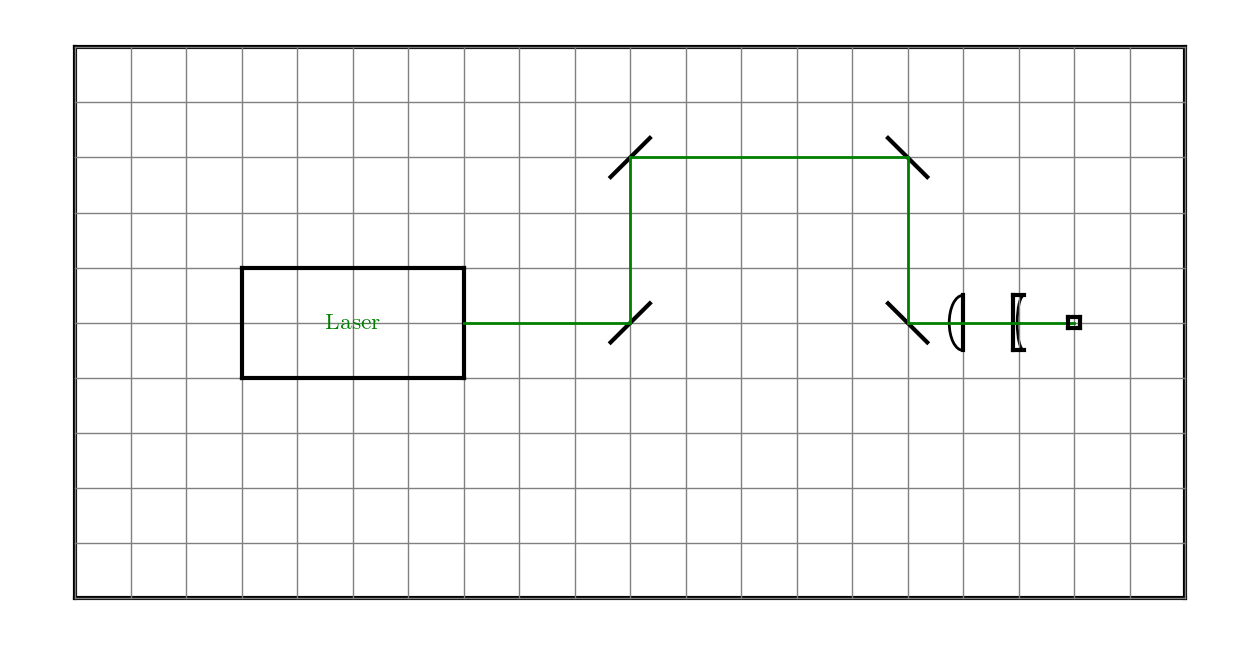

In [13]:
import pyopticaltable as pyopt

# 1. Setup the table (width, height, size_factor for mm scaling)
# Point (0,0) is the center; (-10, -5) is the lower left.
table = pyopt.OpticalTable(20, 10, size_factor=10, show_edge=True, show_grid=True)

# 2. Define your beam and a path list to store components the beam hits
beam = pyopt.LaserBeam(colour='green')
beampath = []

# 3. Add a Laser Source
# Center at (-8, 0), width 4, height 2, pointing right
laser = table.box_source(-5,0, 4, 2, 0, colour='k', output_side='right',label='Laser', textcolour='green', labelpad=0)
beampath.append(laser)

# 4. Add a Mirror to reflect the beam
mirrorsize = 0.5
mirror1 = table.mirror(0,0,mirrorsize,45)
beampath.append(mirror1)

mirror2 = table.mirror(0,3,mirrorsize,45)
beampath.append(mirror2)

mirror3 = table.mirror(5,3,mirrorsize,-45)
beampath.append(mirror3)

mirror4 = table.mirror(5,0,mirrorsize,-45)
beampath.append(mirror4)

L1 = table.convex_lens(6, 0, mirrorsize, 90)
beampath.append(L1)

L2 = table.concave_lens(7, 0, mirrorsize, 270)
beampath.append(L2)

dump = table.beam_dump(8, 0, 0.1, 0, fillcolour='k')
beampath.append(dump)

# 6. Route the beam through all components in the beampath list
beam.draw(table, beampath)